In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from astropy.time import Time

In [2]:
# Function to convert a date string to a datetime object
def convert_to_datetime(date_str):
    # List of possible date formats
    date_formats = [
        '%Y-%m-%d %H:%M:%S',
        '%Y/%m/%d %H%M',
        '%Y/%m/%d %H%M(%S)',
        '%Y/%m/%d %H%M(S)',
        '%Y/%m/%d %H:%M',
        '%Y/%m/%d %H:%M:%S',
        '%Y/%m/%d %H:%M(S)',
        '%d/%m/%Y %H:%M'
    ]
    for date_format in date_formats:
        try:
            return datetime.strptime(date_str, date_format)
        except ValueError:
            continue
    # If no format matches, return None
    return None
    
# Function to convert Time_Error from string to timedelta
def convert_to_timedelta(time_str):
    try:
        return pd.to_timedelta(time_str)
    except ValueError:
        return None

In [4]:
crlist = pd.read_csv("/Users/dven/repos/Pulse_Duration_Calibration/data/input/(I)CMEs_SingleEvents.csv")

In [5]:
# Convert date columns to datetime objects using datetime library
date_columns = ['CME_Time', 'Time_21.5', 'ICME_Start_Time', 'ICME_End_Time', 'Disturbance_Time']
for column in date_columns:
    crlist[column] = crlist[column].apply(lambda x: convert_to_datetime(x) if isinstance(x, str) else None)
    
crlist['tt_icme'] = np.nan 
for irow in range(0, len(crlist)):
    crlist.loc[irow,'tt_icme'] = crlist.loc[irow,'Disturbance_Time'] - crlist.loc[irow,'Time_21.5']
# Convert  from timedelta to days
crlist['tt_icme'] = crlist['tt_icme'].apply(lambda x: x.days + x.seconds / 86400 if isinstance(x, timedelta) else None)

crlist['v_eff'] = np.nan
distance = (149.597e6 - 21.5*696340)
for irow in range(0, len(crlist)):
    crlist.loc[irow,'v_eff'] = distance/(crlist.loc[irow,'tt_icme']*24*60*60)

In [28]:
crlist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ICME              97 non-null     object        
 1   CME               97 non-null     object        
 2   -                 97 non-null     object        
 3   Disturbance_Time  97 non-null     datetime64[ns]
 4   ICME_Start_Time   97 non-null     datetime64[ns]
 5   ICME_End_Time     97 non-null     datetime64[ns]
 6   V_ICME            97 non-null     int64         
 7   V_max             97 non-null     int64         
 8   B                 97 non-null     int64         
 9   MC                97 non-null     int64         
 10  -                 97 non-null     object        
 11  CME_Time          97 non-null     datetime64[ns]
 12  Time_21.5         97 non-null     datetime64[ns]
 13  lat               97 non-null     int64         
 14  lon               97 non-nul

In [11]:
cr_sorted = crlist.sort_values('ICME_Start_Time').reset_index(drop=True)

t = cr_sorted['ICME_Start_Time']

# Differences forward and backward
dt_prev = t.diff().abs()
dt_next = t.diff(-1).abs()

mask = ~(
    (dt_prev < pd.Timedelta(days=5)) |
    (dt_next < pd.Timedelta(days=5))
)

cr = cr_sorted[mask].reset_index(drop=True)

In [12]:
cr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ICME              64 non-null     object        
 1   CME               64 non-null     object        
 2   -                 64 non-null     object        
 3   Disturbance_Time  64 non-null     datetime64[ns]
 4   ICME_Start_Time   64 non-null     datetime64[ns]
 5   ICME_End_Time     64 non-null     datetime64[ns]
 6   V_ICME            64 non-null     int64         
 7   V_max             64 non-null     int64         
 8   B                 64 non-null     int64         
 9   MC                64 non-null     int64         
 10  -                 64 non-null     object        
 11  CME_Time          64 non-null     datetime64[ns]
 12  Time_21.5         64 non-null     datetime64[ns]
 13  lat               64 non-null     int64         
 14  lon               64 non-nul

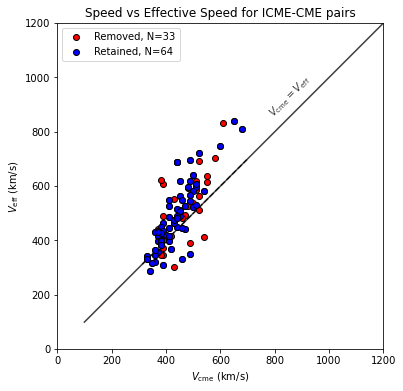

In [34]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(crlist['V_ICME'],crlist['v_eff'], c = 'red', edgecolors = 'black', label='Removed, N=33')
ax.scatter(cr['V_ICME'],cr['v_eff'], c = 'blue', edgecolors = 'black', label='Retained, N=64')

# plot y = x line
xmin, xmax = ax.get_xlim()
ax.plot([xmin, xmax], [xmin, xmax], 'k--', alpha=0.75, zorder=0)

# add label along the line
x_text = 1.10 * xmax          # position along x
y_text = 1.10 * x_text               # since y = x
ax.text(
    x_text, y_text,
    r'$V_{\mathrm{cme}} = V_{\mathrm{eff}}$',
    rotation=45,
    color='black',
    alpha=0.8,
    ha='left',
    va='bottom'
)

ax.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
ax.set_xlim(0, 1200)
ax.set_ylim(0, 1200)
ax.set_xlabel(r'$V_{\mathrm{cme}}$ (km/s)')
ax.set_ylabel(r'$V_{\mathrm{eff}}$ (km/s)')
ax.set_title('Speed vs Effective Speed for ICME-CME pairs')
ax.set_aspect('equal')
ax.legend()
fig.savefig('filtered_icme.pdf', format='pdf')

In [35]:
cr.to_csv('cr.csv', index=False)